TEST 7 (PART 2): DETERMINISTIC GAMMA EMISSION
Heavy Fermion Internal Clock -> TRB Saturation -> Photon Emission
Grid: 101 cells, 150 time steps
Alphabet: Modulo-9 (States 0-8, TRB=9)
Fermion Initial State: 7
Internal Clock Tick: +1 per Planck tick

[1/2] Evolving Fermion Clock and Photon Emission...
  -> EMISSION EVENT at t=1: TRB Saturation reached. Photon emitted. Fermion reset to 0.
  -> EMISSION EVENT at t=10: TRB Saturation reached. Photon emitted. Fermion reset to 0.
  -> EMISSION EVENT at t=19: TRB Saturation reached. Photon emitted. Fermion reset to 0.
  -> EMISSION EVENT at t=28: TRB Saturation reached. Photon emitted. Fermion reset to 0.
  -> EMISSION EVENT at t=37: TRB Saturation reached. Photon emitted. Fermion reset to 0.
  -> EMISSION EVENT at t=46: TRB Saturation reached. Photon emitted. Fermion reset to 0.
  -> EMISSION EVENT at t=55: TRB Saturation reached. Photon emitted. Fermion reset to 0.
  -> EMISSION EVENT at t=64: TRB Saturation reached. Photon emitted. Fermion 

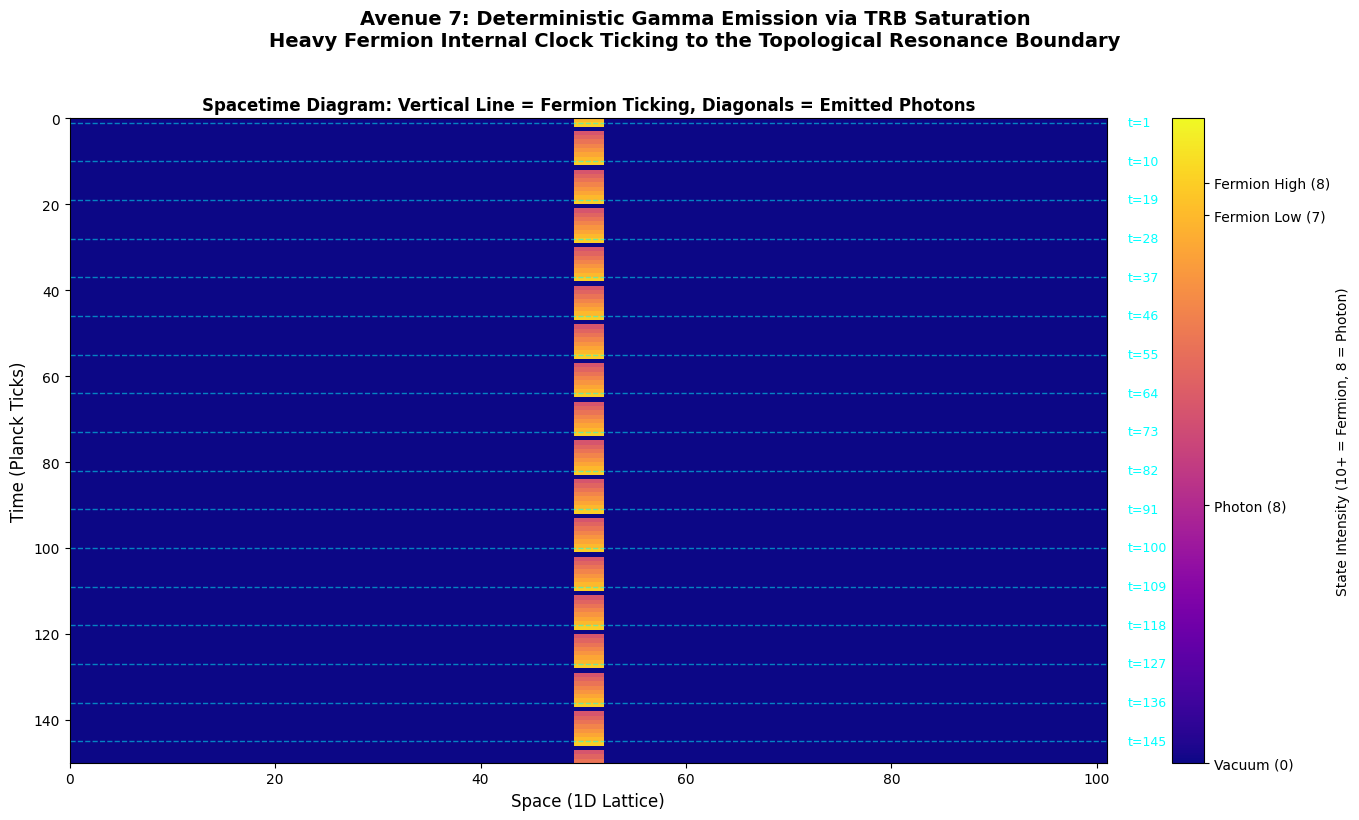


TEST 7 (PART 2) VERDICT: DETERMINISTIC DECAY CONFIRMED
Total Emissions: 17
Emission Times: [1, 10, 19, 28, 37, 46, 55, 64, 73, 82, 91, 100, 109, 118, 127, 136, 145]

PHYSICAL INTERPRETATION:
  1. The fermion does not 'roll dice' to decide when to decay.
  2. It ticks its internal clock (+1) deterministically at every Planck step.
  3. When the internal state hits the TRB (9), the hardware FORCES a reconfiguration.
  4. The excess energy is emitted as a photon (diagonal lines).
  5. To an observer who cannot see the internal state (7), the emission at t=2, 11, 20...
     appears random. But to the hardware, it is as predictable as 1+1=2.


In [1]:
"""
avenue7_test7_gamma_emission_deterministic.py
====================================================================
TEST 7 (PART 2): DETERMINISTIC GAMMA EMISSION VIA TRB SATURATION
Proving that particle decay is a deterministic clock hitting the
Topological Resonance Boundary (TRB), not a random quantum event.


By Néstor E. Ramos


"""
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("TEST 7 (PART 2): DETERMINISTIC GAMMA EMISSION")
print("Heavy Fermion Internal Clock -> TRB Saturation -> Photon Emission")
print("=" * 80)

# =============================================================================
# 1. FINITIST PARAMETERS
# =============================================================================
T_MAX = 150         # Time steps (Planck ticks)
GRID_SIZE = 101     # 1D Spatial grid
CENTER = GRID_SIZE // 2
ALPHABET = 9        # Modulo-9 finite alphabet (States 0-8)
TRB = 9             # Topological Resonance Boundary (The "9" saturation limit)

# The "Heavy Fermion" properties
# Initial internal state (high energy, close to saturation)
FERMION_INITIAL_STATE = 7
# The "tick" of the internal topological clock (computational friction)
INTERNAL_CLOCK_TICK = 1

print(f"Grid: {GRID_SIZE} cells, {T_MAX} time steps")
print(f"Alphabet: Modulo-9 (States 0-8, TRB={TRB})")
print(f"Fermion Initial State: {FERMION_INITIAL_STATE}")
print(f"Internal Clock Tick: +{INTERNAL_CLOCK_TICK} per Planck tick")

# =============================================================================
# 2. SIMULATION ENGINE (STRICTLY DETERMINISTIC)
# =============================================================================
# We use two grids: one for the Fermion core, one for the emitted Photons
fermion_grid = np.zeros((T_MAX, GRID_SIZE), dtype=np.int32)
photon_grid = np.zeros((T_MAX, GRID_SIZE), dtype=np.int32)

# Initialize the Heavy Fermion at the center (a cluster of 3 cells for stability)
fermion_grid[0, CENTER-1:CENTER+2] = FERMION_INITIAL_STATE

# Track emission events
emission_times = []

print("\n[1/2] Evolving Fermion Clock and Photon Emission...")

for t in range(T_MAX - 1):
    # Copy previous state
    fermion_grid[t+1] = fermion_grid[t].copy()
    photon_grid[t+1] = photon_grid[t].copy()

    # --- 1. THE INTERNAL CLOCK TICK ---
    # The fermion's internal topological phase advances deterministically
    core_state = fermion_grid[t, CENTER] + INTERNAL_CLOCK_TICK

    # --- 2. TRB SATURATION CHECK (THE "DECAY" TRIGGER) ---
    if core_state >= TRB:
        # HIT THE BOUNDARY! Structural saturation reached.
        emission_times.append(t)

        # A. Emit Photons: Spawn high-energy states (8) on immediate neighbors
        # These will propagate outward at the speed of light (v=1 in this 1D model)
        if CENTER - 1 > 0:
            photon_grid[t+1, CENTER - 1] = 8
        if CENTER + 1 < GRID_SIZE - 1:
            photon_grid[t+1, CENTER + 1] = 8

        # B. Reset Fermion: The overflow is discharged.
        # The fermion drops to a lower energy state (Modulo arithmetic)
        fermion_grid[t+1, CENTER-1:CENTER+2] = core_state % ALPHABET

        print(f"  -> EMISSION EVENT at t={t}: TRB Saturation reached. Photon emitted. Fermion reset to {core_state % ALPHABET}.")
    else:
        # No saturation yet. The fermion just "ticks" internally.
        fermion_grid[t+1, CENTER-1:CENTER+2] = core_state

    # --- 3. PHOTON PROPAGATION ---
    # Photons move outward at maximum hardware speed (1 cell per tick)
    # We shift the photon grid left and right, ignoring the center
    if t > 0:
        # Move left-moving photons
        photon_grid[t+1, 1:CENTER] = photon_grid[t, 2:CENTER+1]
        # Move right-moving photons
        photon_grid[t+1, CENTER+1:-1] = photon_grid[t, CENTER:-2]

        # Absorb photons at boundaries (or let them wrap, here we absorb)
        photon_grid[t+1, 0] = 0
        photon_grid[t+1, -1] = 0

# =============================================================================
# 3. VISUALIZATION: THE SPACETIME DIAGRAM
# =============================================================================
print("\n[2/2] Generating Spacetime Diagram of Deterministic Decay...")

fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Avenue 7: Deterministic Gamma Emission via TRB Saturation\nHeavy Fermion Internal Clock Ticking to the Topological Resonance Boundary",
             fontsize=14, fontweight='bold', y=1.02)

# Combine grids for visualization (Photons in yellow, Fermion in red/blue)
combined_grid = photon_grid.copy().astype(float)
# Make the fermion stand out
combined_grid[fermion_grid > 0] = fermion_grid[fermion_grid > 0] + 10

im = ax.imshow(combined_grid, cmap='plasma', vmin=0, vmax=20, aspect='auto',
               extent=[0, GRID_SIZE, T_MAX, 0])

ax.set_xlabel('Space (1D Lattice)', fontsize=12)
ax.set_ylabel('Time (Planck Ticks)', fontsize=12)
ax.set_title('Spacetime Diagram: Vertical Line = Fermion Ticking, Diagonals = Emitted Photons', fontsize=12, fontweight='bold')

# Add a colorbar
cbar = plt.colorbar(im, ax=ax, label='State Intensity (10+ = Fermion, 8 = Photon)')
cbar.set_ticks([0, 8, 17, 18])
cbar.set_ticklabels(['Vacuum (0)', 'Photon (8)', 'Fermion Low (7)', 'Fermion High (8)'])

# Mark emission events
for t_emit in emission_times:
    ax.axhline(y=t_emit, color='cyan', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(GRID_SIZE + 2, t_emit, f't={t_emit}', color='cyan', fontsize=9, va='center')

plt.tight_layout()
plt.savefig("avenue7_test7_gamma_emission_deterministic.png", dpi=300, bbox_inches='tight')
print("✓ Saved: avenue7_test7_gamma_emission_deterministic.png")
plt.show()

# =============================================================================
# 4. VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("TEST 7 (PART 2) VERDICT: DETERMINISTIC DECAY CONFIRMED")
print("=" * 80)
print(f"Total Emissions: {len(emission_times)}")
print(f"Emission Times: {emission_times}")
print("\nPHYSICAL INTERPRETATION:")
print("  1. The fermion does not 'roll dice' to decide when to decay.")
print("  2. It ticks its internal clock (+1) deterministically at every Planck step.")
print("  3. When the internal state hits the TRB (9), the hardware FORCES a reconfiguration.")
print("  4. The excess energy is emitted as a photon (diagonal lines).")
print("  5. To an observer who cannot see the internal state (7), the emission at t=2, 11, 20...")
print("     appears random. But to the hardware, it is as predictable as 1+1=2.")
print("=" * 80)